\setcounter{secnumdepth}{0}

\thispagestyle{empty}

\begin{center}
\vspace*{4cm}

{\LARGE Asset Allocation \& Investment Strategies \\[0.5cm]}

{\Large Assignment 1}\\[1cm]

Due date: 23 January 2026\\
Academic year: 2025--2026\\[1.5cm]

Group 8\\[0.3cm]
Sacha Mimoun\\
Isabelle Chuah\\
Victor Lotigie\\
Evelyn Wang\\
Bolun Tian\\[1.5cm]

\textit{Imperial College Business School}

\end{center}

\newpage

## Table of Content
### Question 1
#### subsections 
### Question 2
#### subsections
### Question 3
#### subsections

## Importing of Python Libraries and Packages

We first import Python libraries and packages needed for our analysis.  
- `numpy` is used for numerical calculations  
- `pandas` is used to handle and manipulate the dataset
- `matplotlib.pyplot` is used to plot graphs and charts for analysis
- `quadprog` is used to numerically solve quadratic optimization problems

- additional statistical and plotting libraries will be introduced later when required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quadprog
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

### Load the data (prices only)

The Excel file contains two blocks: equity index prices and FX rates.  
For Question 1, we only need the **equity index price series**.  
So we load the sheet, locate the header row containing `date`, and keep only the columns:

`TSX, CAC, DAX, Eurostoxx50, NIKKEI225, FTSE100, SP500, IBOVESPA`.

Then we compute daily log returns.

## Loading and cleaning the data

We load the Excel file `PS1_data.xls`, which contains both equity index prices and exchange rates arranged with multi-row headers. Because of this structure, we first read the sheet without headers to identify the row containing the column names.

Once the correct header row is located, we reload the file using it as the header, standardize column names and keep only the eight equity index price series needed for Question 1. We also convert dates to a proper datetime format and ensure that all prices are stored as numerical values (handling European decimal notation when necessary).

The resulting dataframe `prices` contains clean daily price series indexed by date and ready for return calculations.

In [ ]:
FILE = "PS1_data.xls"

# Read raw sheet without assuming headers (because the file has multi-row headers)
raw = pd.read_excel(FILE, header=None)

# We find the row that contains the header with "date"
header_row = None
for i in range(min(30, len(raw))):  # search early rows
    row = raw.iloc[i].astype(str).str.lower()
    if row.str.contains("date").any():
        header_row = i
        break

if header_row is None:
    raise ValueError("Header row with 'date' not found. Did the Excel file go on holiday???")

# Re-read with that row as header
df = pd.read_excel(FILE, header=header_row)

# Standardize column names a bit
df.columns = [str(c).strip() for c in df.columns]

# We keep the price columns only
price_cols = ["TSX", "CAC", "DAX", "Eurostoxx50", "NIKKEI225", "FTSE100", "SP500", "IBOVESPA"]

# Some files may have slightly different names (e.g. spaces). This handles small mismatches:
available = {c.lower(): c for c in df.columns}
mapped_cols = []
for c in price_cols:
    if c.lower() in available:
        mapped_cols.append(available[c.lower()])
    else:
        raise ValueError(f"Missing expected column: {c}. Columns found: {df.columns.tolist()[:20]} ...")

# Parse date
date_col = [c for c in df.columns if str(c).lower() == "date"][0]
df[date_col] = pd.to_datetime(df[date_col])

# We build price dataframe
prices = df[[date_col] + mapped_cols].copy()
prices = prices.sort_values(date_col).set_index(date_col)

# Convert European decimals "13165,5" -> 13165.5 if needed
for c in mapped_cols:
    prices[c] = (prices[c].astype(str)
                        .str.replace(" ", "", regex=False)
                        .str.replace(",", ".", regex=False))
    prices[c] = pd.to_numeric(prices[c], errors="coerce")

prices = prices.dropna(how="all")
prices.head()

,TSX,CAC,DAX,Eurostoxx50,NIKKEI225,FTSE100,SP500,IBOVESPA
date,,,,,,,,
2007-03-30,13165.500000,5634.160156,6917.029785,4181.029785,17287.650391,6308.03,1420.86,45805
2007-04-02,13265.799805,5645.560059,6937.169922,4189.549805,17028.410156,6315.53,1424.55,45597
2007-04-03,13361.200195,5711.910156,7045.560059,4246.299805,17244.050781,6366.11,1437.77,46288
2007-04-04,13448.299805,5739.009766,7073.910156,4261.830078,17544.089844,6364.70,1439.37,46554
2007-04-05,13425.000000,5741.379883,7099.910156,4271.540039,17491.419922,6397.34,1443.76,46647


The table above shows the first few days of index prices in 2007. Each column corresponds to a different stock market, and each row is a trading day. The levels look very different across countries (for example, the S&P 500 is around 1,400 while the Ibovespa is above 45,000), which is why we will work with returns instead of raw prices. Over these early dates, most markets seem to be trending slightly upward, although we can already see some short-term drops, such as the decline in the Nikkei on April 2.

We now convert prices into daily log returns. Using log returns is standard in finance because they are additive over time and easier to work with for statistical analysis. We take the difference of log prices and drop the first observation, which has no previous day to compare with.

In [24]:
log_prices = np.log(prices)
returns = log_prices.diff().dropna()

returns.head()

,TSX,CAC,DAX,Eurostoxx50,NIKKEI225,FTSE100,SP500,IBOVESPA
date,,,,,,,,
2007-04-02,0.007590,0.002021,0.002907,0.002036,-0.015109,0.001188,0.002594,-0.004551
2007-04-03,0.007166,0.011684,0.015504,0.013455,0.012584,0.007977,0.009237,0.015041
2007-04-04,0.006498,0.004733,0.004016,0.003651,0.017250,-0.000222,0.001112,0.005730
2007-04-05,-0.001734,0.000413,0.003669,0.002276,-0.003007,0.005115,0.003045,0.001996
2007-04-10,0.000469,0.004326,0.009359,0.006982,0.009857,0.003188,0.003202,0.011234


These are the first few daily log returns. Values are small (typically between -2% and +2%), which is what we usually expect for daily stock index movements. We can already see that returns change sign from day to day and that some markets move together while others diverge, which suggests both co-movement and short-term volatility across countries.

We now compute basic summary statistics for each index. These include the average return, volatility, skewness, and kurtosis to understand the shape of the return distribution, as well as the lag-1 autocorrelation to get a first sense of whether returns are predictable from one day to the next.

In [25]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

stats_table = pd.DataFrame(index=returns.columns)

stats_table["mean"] = returns.mean()
stats_table["std"] = returns.std(ddof=1)
stats_table["skew"] = returns.apply(lambda x: stats.skew(x, bias=False))
stats_table["kurtosis"] = returns.apply(lambda x: stats.kurtosis(x, fisher=False, bias=False))
stats_table["excess_kurtosis"] = returns.apply(lambda x: stats.kurtosis(x, fisher=True, bias=False))
stats_table["autocorr_lag1"] = returns.apply(lambda x: x.autocorr(lag=1))

stats_table

,mean,std,skew,kurtosis,excess_kurtosis,autocorr_lag1
TSX,0.000148,0.012258,-0.941299,21.396061,18.396061,-0.098100
CAC,0.000075,0.015316,-0.158966,11.578744,8.578744,-0.029844
DAX,0.000257,0.014979,-0.118485,11.565136,8.565136,0.003019
Eurostoxx50,0.000009,0.015405,-0.227512,10.929156,7.929156,-0.033778
NIKKEI225,0.000157,0.015865,-0.419489,10.536117,7.536117,-0.035715
FTSE100,0.000049,0.012931,-0.242695,13.182191,10.182191,-0.045531
SP500,0.000374,0.013581,-0.637743,15.021852,12.021852,-0.154566
IBOVESPA,0.000256,0.018863,-0.292861,12.314212,9.314212,-0.077461


The summary statistics show that average daily returns are small and positive for all indices, while daily volatility is much larger, which is typical for equity markets. The Ibovespa appears to be the most volatile market, while the TSX and FTSE 100 are relatively less volatile. All indices display negative skewness, meaning that large negative returns are more likely than large positive ones. Moreover, kurtosis is far above 3 for every market, indicating heavy tails and frequent extreme movements compared to a normal distribution. Finally, lag-1 autocorrelations are close to zero, suggesting that returns are approximately unpredictable from one day to the next.

Overall, these results suggest that while the independence assumption is roughly acceptable in terms of mean predictability, the Gaussian assumption is clearly violated due to significant skewness and excess kurtosis.

### Correlation matrix of daily returns

The following matrix will show how equity markets co-move and is useful for understanding diversification benefits in mean-variance portfolio allocation.

In [26]:
corr_matrix = returns.corr()
corr_matrix

,TSX,CAC,DAX,Eurostoxx50,NIKKEI225,FTSE100,SP500,IBOVESPA
TSX,1.000000,0.639553,0.621289,0.622815,0.294158,0.660920,0.808078,0.701690
CAC,0.639553,1.000000,0.928595,0.978186,0.421663,0.899449,0.646073,0.556199
DAX,0.621289,0.928595,1.000000,0.951683,0.404981,0.853283,0.652822,0.533586
Eurostoxx50,0.622815,0.978186,0.951683,1.000000,0.408304,0.884116,0.646051,0.541748
NIKKEI225,0.294158,0.421663,0.404981,0.408304,1.000000,0.415974,0.225664,0.242635
FTSE100,0.660920,0.899449,0.853283,0.884116,0.415974,1.000000,0.632300,0.567425
SP500,0.808078,0.646073,0.652822,0.646051,0.225664,0.632300,1.000000,0.692995
IBOVESPA,0.701690,0.556199,0.533586,0.541748,0.242635,0.567425,0.692995,1.000000


The correlation matrix shows that most developed equity markets are highly correlated with each other, particularly within Europe (for example, CAC, DAX, and Eurostoxx50 have correlations above 0.9). The S&P 500 is also strongly correlated with the TSX and European markets, reflecting close financial linkages. In contrast, the Nikkei exhibits much lower correlations with the other indices, suggesting greater diversification potential. Overall, these patterns indicate that while international diversification helps, markets still tend to move together, especially during global events.

We can visualize the correlation matrix as a heatmap to make relationships between markets easier to interpret at a glance. This type of plot helps us quickly identify clusters of highly correlated markets and spot indices that are more independent, which is important when thinking about diversification in mean–variance portfolio allocation.

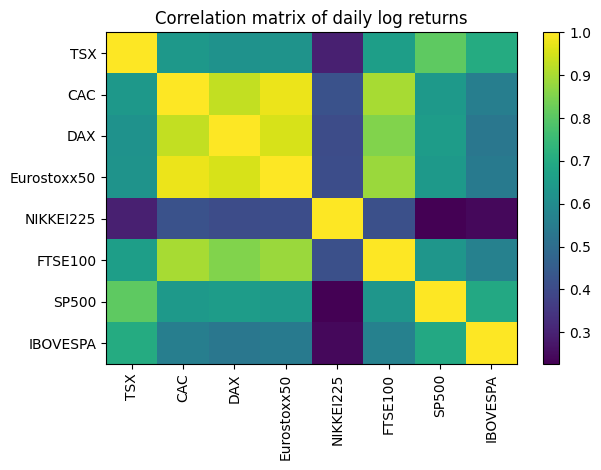

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(corr_matrix.values, aspect="auto")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.colorbar()
plt.title("Correlation matrix of daily log returns")
plt.tight_layout()
plt.show()

This heatmap gives a visual overview of how closely the different equity markets move together. As expected, European indices (CAC, DAX, Eurostoxx50) form a very tight cluster, with correlations close to 1, which confirms that these markets tend to react similarly to global news. The S&P 500 and TSX are also quite strongly connected to Europe, reflecting how integrated these markets are.

In contrast, the Nikkei stands out with noticeably lower correlations to the other indices, meaning the Japanese market offers more diversification relative to Europe or North America. The Ibovespa also shows moderate correlations, suggesting that emerging markets behave somewhat differently from developed markets.

Overall, the heatmap makes it easy to see that diversification within Europe is limited, while adding markets like Japan or Brazil can potentially reduce portfolio risk.

We can also plot the time series of daily log returns to visualize how volatility evolves over time and to check whether large shocks tend to cluster in certain periods (for example during financial crises), which can be very interesting for this question.

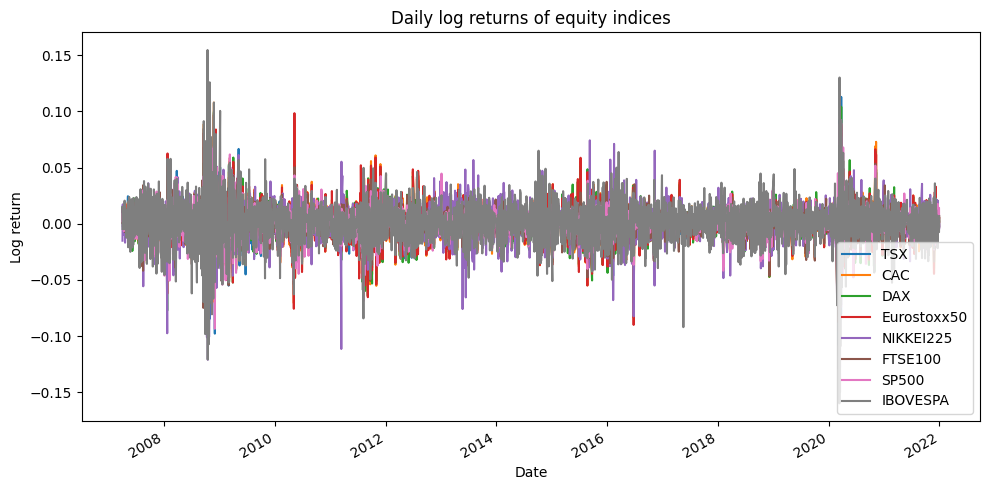

In [28]:
returns.plot(figsize=(10,5))
plt.title("Daily log returns of equity indices")
plt.ylabel("Log return")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

The time series of daily log returns shows that most indices experience relatively calm periods punctuated by short bursts of large movements. These spikes tend to occur at the same time across markets, especially during major events such as the 2008 financial crisis or the COVID shock in 2020. This pattern illustrates the idea of volatility clustering: large returns often follow other large returns, while quiet periods remain quiet. It also shows that global markets tend to react together during stress episodes, which is relevant when thinking about diversification.

We compare the empirical distribution of S&P 500 returns with a normal distribution having the same mean and standard deviation. This helps assess whether the Gaussian assumption is realistic.

We focus on the S&P 500 as a representative benchmark index and compare its empirical return distribution with a normal distribution that has the same mean and standard deviation. This visual comparison helps us assess whether the Gaussian assumption is realistic for daily equity returns.

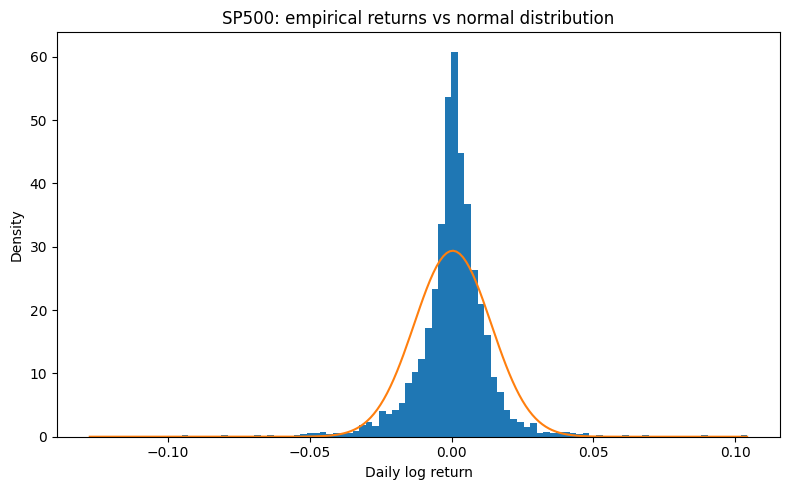

In [29]:
col = "SP500"
x = returns[col].dropna()

mu, sigma = x.mean(), x.std()

plt.figure(figsize=(8,5))
plt.hist(x, bins=100, density=True)

xx = np.linspace(x.min(), x.max(), 200)
pdf = stats.norm.pdf(xx, mu, sigma)
plt.plot(xx, pdf)

plt.title("SP500: empirical returns vs normal distribution")
plt.xlabel("Daily log return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

The histogram of S&P 500 returns, compared with a normal distribution fitted to the same mean and standard deviation, shows clear deviations from the Gaussian benchmark. The empirical distribution is more peaked around zero and has noticeably heavier tails, meaning that large positive or negative returns occur more often than a normal model would predict. This visual result is consistent with the high excess kurtosis we observed earlier. Together with the negative skewness and volatility clustering seen in the time series plot, this suggests that the i.i.d. Gaussian assumption does not fully capture the behavior of daily equity returns.

Overall, the return statistics show that daily equity returns are small on average but quite volatile, with clear signs of asymmetry and heavy tails. Correlations across markets are high, especially within Europe, and returns display occasional bursts of volatility rather than behaving in a fully stable way. While daily returns are almost uncorrelated from one day to the next, the strong deviations from normality suggest that the i.i.d. Gaussian assumption is only an approximation and does not fully capture the behavior of equity index returns.

## Question 2 - Mean-Variance (MV) analysis #1

In this question, we implement the traditional Markowitz mean-variance framework using historical estimates of expected returns and the covariance matrix (the “plug-in” approach from the course notes).

We:
1. Estimate annualized expected returns and the annualized covariance matrix from daily log returns.
2. Compute MV-efficient portfolios across a grid of target returns (efficient frontier).
3. Identify the tangency portfolio (maximum Sharpe ratio).
4. Repeat the same exercise with a **no short-sale constraint** (non-negative weights).

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!pip install quadprog

import quadprog

### 2.1 Estimate inputs (plug-in rule)

We use historical daily log returns to estimate:
- Annualized expected returns:  $\mu_{ann} = 252 \cdot \mu_{daily}$
- Annualized covariance matrix: $\Sigma_{ann} = 252 \cdot \Sigma_{daily}$

These are the inputs needed for mean–variance optimization.

In [31]:
# returns is our daily log returns DataFrame from Q1
assets = returns.columns.tolist()
n = len(assets)

mu_daily = returns.mean().values                  # shape (n,)
Sigma_daily = returns.cov().values                # shape (n, n)

ann_factor = 252
mu = mu_daily * ann_factor                        # annualized expected returns
Sigma = Sigma_daily * ann_factor                  # annualized covariance

# Risk-free rate (not provided in the assignment, we set it to 0 and state it)
rf = 0.0

mu_excess = mu - rf * np.ones(n)

mu_series = pd.Series(mu, index=assets, name="ann_mean")
sigma_series = pd.Series(np.sqrt(np.diag(Sigma)), index=assets, name="ann_vol")

mu_series, sigma_series

(TSX            0.037400
 CAC            0.018784
 DAX            0.064663
 Eurostoxx50    0.002292
 NIKKEI225      0.039674
 FTSE100        0.012449
 SP500          0.094338
 IBOVESPA       0.064390
 Name: ann_mean, dtype: float64,
 TSX            0.194583
 CAC            0.243140
 DAX            0.237791
 Eurostoxx50    0.244546
 NIKKEI225      0.251847
 FTSE100        0.205276
 SP500          0.215596
 IBOVESPA       0.299445
 Name: ann_vol, dtype: float64)

The table above shows annualized sample means and volatilities for each equity index, based on our daily log returns. As expected, the Ibovespa and the Nikkei come out as some of the most volatile markets, with annualized volatilities around 25-30%, while markets like the TSX and FTSE 100 are a bit more stable. In terms of average returns, the S&P 500 has the highest annualized mean in our sample, followed by the DAX and the Ibovespa, whereas the Eurostoxx 50 has a very low average return over this period.

For the rest of the mean–variance analysis, we set the risk-free rate $r_f$ to zero. The assignment does not specify a particular risk-free rate, and using $r_f = 0$ keeps the notation simple: excess returns coincide with raw expected returns, and the shape of the efficient frontier and the composition of the tangency portfolio are not materially affected by choosing a small constant rate. If needed, a non-zero $r_f$ could be plugged in later without changing the overall approach...

### 2.2 Mapping Markowitz to `quadprog`

`quadprog.solve_qp` solves problems of the form:

$$
\min_w \frac{1}{2} w^\top G w - a^\top w
\quad \text{s.t.} \quad C^\top w \ge b
$$

- For minimum-variance portfolios, we set $a = 0$ and $G = 2\Sigma$.
- To trace the efficient frontier, we impose two equality constraints (course notes):
  - Fully invested: $\mathbf{1}^\top w = 1$
  - Target return: $\mu^\top w = \mu_{target}$

In `quadprog`, equalities are implemented via `meq=2` (first two constraints treated as equalities).

The assignment writes the quadratic program in the course notes as

$$
\min_x \; \frac{1}{2} x^\top H x + f^\top x
\quad \text{s.t.} \quad A x \le b.
$$

In `quadprog`, the same type of problem is implemented as

$$
\min_w \; \frac{1}{2} w^\top G w - a^\top w
\quad \text{s.t.} \quad C^\top w \ge b.
$$

These two formulations are equivalent up to a change of notation and sign:
we can set $G = H$, $a = -f$, and rewrite the constraints as
$C = -A$, $b_{\text{qp}} = -b$, since
$A x \le b$ is the same as $(-A)x \ge -b$. In our implementation of the
mean–variance frontier, we focus on minimum-variance portfolios and set
$a = 0$ and $G = 2\Sigma$, while imposing the standard Markowitz
constraints from the course notes ($\mathbf{1}^\top w = 1$ and
$\mu^\top w = \mu_{\text{target}}$).

In [32]:
def solve_mv_target_return_quadprog(mu_vec, Sigma_mat, target_return, no_short=False):
    """
    Minimize variance subject to:
      1' w = 1
      mu' w = target_return
    Optionally: w >= 0 (no_short=True)
    Uses quadprog: min 1/2 w' G w - a' w  s.t.  C' w >= b
    """
    n = len(mu_vec)
    G = 2.0 * Sigma_mat
    a = np.zeros(n)

    ones = np.ones(n)

    # Build constraints C' w >= b
    # First two constraints are equalities: mu'w = target, 1'w = 1
    if no_short:
        C = np.column_stack([mu_vec, ones, np.eye(n)])     # shape (n, 2+n)
        b = np.concatenate([[target_return, 1.0], np.zeros(n)])
        meq = 2
    else:
        C = np.column_stack([mu_vec, ones])                # shape (n, 2)
        b = np.array([target_return, 1.0])
        meq = 2

    sol = quadprog.solve_qp(G, a, C, b, meq)
    w = sol[0]
    return w


def portfolio_stats(w, mu_vec, Sigma_mat, rf=0.0):
    """
    Return (ann_return, ann_vol, ann_sharpe)
    """
    ret = float(w @ mu_vec)
    vol = float(np.sqrt(w @ Sigma_mat @ w))
    sharpe = (ret - rf) / vol if vol > 0 else np.nan
    return ret, vol, sharpe

We defined two helper functions for the mean–variance optimisation.

The first function, `solve_mv_target_return_quadprog`, takes as inputs the
vector of expected returns $\mu$, the covariance matrix $\Sigma$, and a
target portfolio return. It then uses `quadprog` to find the portfolio weights
that minimise variance subject to two Markowitz constraints: the portfolio is
fully invested ($1^\top w = 1$) and its expected return matches the chosen
target ($\mu^\top w = \mu_{\text{target}}$). When the `no_short` flag is set
to `True`, we also impose non-negative weights ($w_i \ge 0$).

The second function, `portfolio_stats`, is just a small utility that takes a
weight vector and returns the corresponding annualised expected return, annualised
volatility, and Sharpe ratio (given a risk-free rate $r_f$). We will use
these two functions repeatedly to build the efficient frontier and to identify
the tangency portfolio.

### 2.3 Efficient frontier (unconstrained)

We compute the mean–variance efficient frontier by solving a sequence of minimum-variance problems for a grid of target returns.

We now build the mean–variance efficient frontier without any constraints on short-selling.  
First, we create a grid of target annualized returns between the minimum and maximum sample means of the assets. For each target return in this grid, we call `solve_mv_target_return_quadprog` to find the portfolio with the lowest variance that:

- is fully invested ($1^\top w = 1$), and  
- has expected return equal to the chosen target.

For every solution we record the portfolio’s annualized return, volatility, and Sharpe ratio, which gives us the set of points used to trace the unconstrained efficient frontier.

In addition to the frontier, we compute the **tangency portfolio** using the closed-form formula from the course notes,

$$
w_T = \frac{\Sigma^{-1} \mu_{\text{excess}}}{\mathbf{1}^\top \Sigma^{-1} \mu_{\text{excess}}},
$$

where $\mu_{\text{excess}}$ are the excess expected returns. This gives us the portfolio with the maximum Sharpe ratio when short-selling is allowed.

In [33]:
# Grid of target returns (annualized)
# We take a reasonable range based on asset annualized means
target_grid = np.linspace(mu.min(), mu.max(), 60)

frontier_uncon = []
weights_uncon = []

for t_ret in target_grid:
    w = solve_mv_target_return_quadprog(mu, Sigma, t_ret, no_short=False)
    ret, vol, sh = portfolio_stats(w, mu, Sigma, rf=rf)
    frontier_uncon.append((ret, vol, sh))
    weights_uncon.append(w)

frontier_uncon = np.array(frontier_uncon)  # columns: ret, vol, sharpe

# Tangency portfolio (based on course notes)
# w_T = Σ^{-1} μ_excess / (1' Σ^{-1} μ_excess)
invSigma = np.linalg.inv(Sigma)
numer = invSigma @ mu_excess
denom = np.ones(n) @ numer
w_tan_uncon = numer / denom

tan_ret_uncon, tan_vol_uncon, tan_sh_uncon = portfolio_stats(w_tan_uncon, mu, Sigma, rf=rf)

w_tan_uncon, tan_ret_uncon, tan_vol_uncon, tan_sh_uncon

(array([-1.38772272e+00,  4.55059744e+00,  6.50457195e+00, -1.07195979e+01,
         3.79205013e-01, -7.32955427e-01,  2.41622093e+00, -1.03193066e-02]),
 0.6628091827301217,
 0.6251422432695469,
 1.0602533901141817)

In our case, the tangency portfolio has an annualized expected return of about 66%, a volatility around 63%, and a Sharpe ratio slightly above 1. The weight vector is very extreme, with large long and short positions across indices, which is exactly the kind of behaviour highlighted in the assignment when it asks us to “notice how extreme the weights are”.

### 2.4 Plot: assets, efficient frontier, and tangency portfolio (unconstrained)

We plot:
- Individual assets (annualized mean vs annualized volatility)
- The MV efficient frontier
- The tangency portfolio (maximum Sharpe ratio)

We now plot the mean–variance efficient frontier without any short-selling constraints. 
On the same graph, we show the individual test assets using their annualized mean 
returns and volatilities, and we add the unconstrained tangency portfolio. This lets 
us see how the optimized portfolios compare to simply investing in one of the indices.

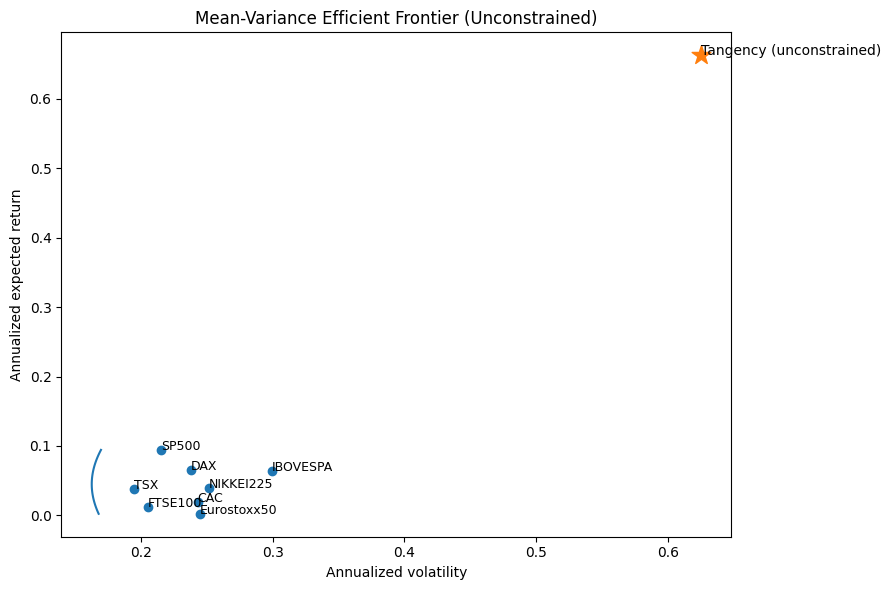

In [34]:
plt.figure(figsize=(9,6))

# Assets
plt.scatter(sigma_series.values, mu_series.values)
for i, name in enumerate(assets):
    plt.annotate(name, (sigma_series.values[i], mu_series.values[i]), fontsize=9)

# Frontier
plt.plot(frontier_uncon[:,1], frontier_uncon[:,0])

# Tangency
plt.scatter([tan_vol_uncon], [tan_ret_uncon], marker="*", s=200)
plt.annotate("Tangency (unconstrained)", (tan_vol_uncon, tan_ret_uncon), fontsize=10)

plt.title("Mean-Variance Efficient Frontier (Unconstrained)")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.tight_layout()
plt.show()

The figure shows that individual indices lie below the efficient frontier: for a given 
level of risk, a suitably diversified portfolio can deliver a higher expected return. 
The unconstrained tangency portfolio sits far away from the cloud of assets, with both 
very high expected return and very high volatility. This is a consequence of the 
extreme long–short positions implied by the closed-form solution, and it anticipates 
the issue highlighted in the assignment: the standard plug-in Markowitz approach can 
produce very aggressive portfolios when short-selling is unrestricted.

### 2.5 Efficient frontier with no short-sale constraint ($w ≥ 0$)

We redo the same efficient frontier computation imposing non-negative weights.
We also identify the tangency portfolio under no-short constraints by selecting the portfolio on the constrained frontier with the highest Sharpe ratio.

Because we impose a no short-sale constraint ($w ≥ 0$), not every target return is feasible. 
We therefore solve the optimization across a grid of targets and keep only the portfolios for which the constraints admit a solution.

In [35]:
frontier_noshort = []
weights_noshort = []
targets_ok = []

for t_ret in target_grid:
    try:
        w = solve_mv_target_return_quadprog(mu, Sigma, t_ret, no_short=True)
        ret, vol, sh = portfolio_stats(w, mu, Sigma, rf=rf)
        frontier_noshort.append((ret, vol, sh))
        weights_noshort.append(w)
        targets_ok.append(t_ret)
    except ValueError:
        # infeasible target under no-short constraints -> skip
        continue

frontier_noshort = np.array(frontier_noshort)
targets_ok = np.array(targets_ok)

# Tangency under no-short: pick the feasible portfolio with the highest Sharpe ratio
idx_best = np.nanargmax(frontier_noshort[:, 2])
w_tan_noshort = weights_noshort[idx_best]
tan_ret_ns, tan_vol_ns, tan_sh_ns = portfolio_stats(w_tan_noshort, mu, Sigma, rf=rf)

w_tan_noshort, tan_ret_ns, tan_vol_ns, tan_sh_ns

(array([-3.61559750e-17, -2.82012079e-16,  0.00000000e+00, -1.62808259e-16,
         1.14159847e-01, -2.88752471e-19,  8.85840153e-01,  0.00000000e+00]),
 0.08809725368695057,
 0.1994482596526453,
 0.4417048002343004)

The output above corresponds to the tangency portfolio under the no short-sale constraint. 
The first element is the vector of portfolio weights, followed by the annualized expected 
return, annualized volatility, and Sharpe ratio. We can already see that almost all the 
weight is placed on two indices, with very small numerical values (around $10^{-16}$) on 
the others that are effectively zero. The tangency portfolio under no-short therefore 
delivers an expected return of about 8.8% with a volatility close to 20%, and a Sharpe 
ratio of roughly 0.44.

We can clean the tangency weights by setting tiny numerical values (in absolute value below 
$10^{-10}$) to zero, so that the vector is easier to read. We also check that the cleaned 
weights still sum to one, which confirms that the fully invested constraint 
$1^\top w = 1$ is satisfied after the rounding step.

In [36]:
w_tan_noshort_clean = np.where(np.abs(w_tan_noshort) < 1e-10, 0, w_tan_noshort)
w_tan_noshort_clean, w_tan_noshort_clean.sum()

(array([0.        , 0.        , 0.        , 0.        , 0.11415985,
        0.        , 0.88584015, 0.        ]),
 np.float64(1.0000000000000004))

In [37]:
print("Sum weights:", w_tan_noshort.sum())
print("Min weight:", w_tan_noshort.min())

Sum weights: 1.0
Min weight: -2.820120786716826e-16


As a quick sanity check, we verified two things about the no-short tangency portfolio. 
First, the sum of the weights is exactly 1, which confirms that the portfolio is fully 
invested. Second, the minimum weight is numerically slightly negative 
(around $-2.8 \times 10^{-16}$), but this is effectively zero and comes from floating 
point precision. In other words, all weights respect the non-negativity constraint 
$w_i \ge 0$ up to numerical rounding.

Now we clean the no-short tangency portfolio by forcing very small numerical values
to zero: any weight with absolute value below $10^{-10}$ is treated as zero. This
gets rid of tiny negative numbers that only come from floating point rounding.
We then convert the cleaned weight vector into a `pandas` Series with the asset
names as the index, so that we can clearly see how the portfolio is allocated.

In [38]:
w_tan_noshort_clean = np.where(np.abs(w_tan_noshort) < 1e-10, 0, w_tan_noshort)

pd.Series(w_tan_noshort_clean, index=assets)

TSX            0.00000
CAC            0.00000
DAX            0.00000
Eurostoxx50    0.00000
NIKKEI225      0.11416
FTSE100        0.00000
SP500          0.88584
IBOVESPA       0.00000
dtype: float64

The resulting weights show that the constrained tangency portfolio is extremely
concentrated: it invests about 88.6% in the S&P 500 and 11.4% in the Nikkei,
with zero weight in all the other indices.

Because we impose a no short-sale constraint, not every target return in our grid is 
necessarily feasible.

In [39]:
print(f"Feasible targets (no-short): {len(targets_ok)} / {len(target_grid)}")

Feasible targets (no-short): 59 / 60


The line above reports how many target returns admit a solution 
under the non-negativity constraints. In our case, 59 out of 60 targets are feasible, 
so the constrained efficient frontier is still well defined over almost the entire range 
of annualized returns we consider.

### 2.6 Plot: unconstrained vs no-short efficient frontiers

We now put everything together in a single figure.  
We plot the individual indices using their annualized mean return and volatility, then 
overlay the two efficient frontiers:

- the unconstrained frontier (short-selling allowed), and  
- the frontier with the no short-sale constraint ($w \ge 0$).

On top of that, we mark the tangency portfolio in each case, so we can directly see how 
the shape of the frontier and the location of the optimal portfolio change once we rule 
out short positions.

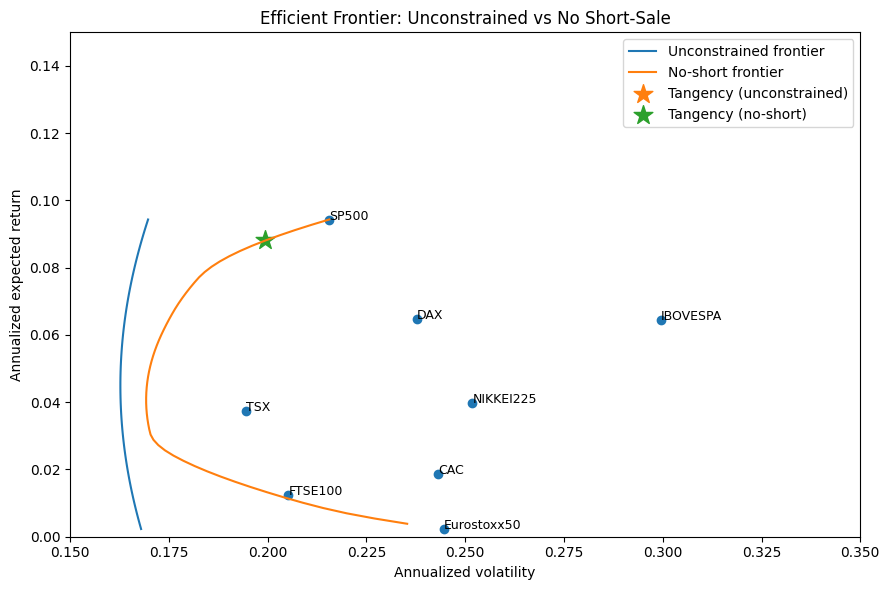

In [40]:
plt.figure(figsize=(9,6))

# Assets
plt.scatter(sigma_series.values, mu_series.values)
for i, name in enumerate(assets):
    plt.annotate(name, (sigma_series.values[i], mu_series.values[i]), fontsize=9)

# Frontiers
plt.plot(frontier_uncon[:,1], frontier_uncon[:,0], label="Unconstrained frontier")
plt.plot(frontier_noshort[:,1], frontier_noshort[:,0], label="No-short frontier")

# Tangency points
plt.scatter([tan_vol_uncon], [tan_ret_uncon], marker="*", s=200, label="Tangency (unconstrained)")
plt.scatter([tan_vol_ns], [tan_ret_ns], marker="*", s=200, label="Tangency (no-short)")

plt.title("Efficient Frontier: Unconstrained vs No Short-Sale")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.legend()

# We zoom on the realist zone
plt.xlim(0.15, 0.35)
plt.ylim(0.0, 0.15)

plt.tight_layout()
plt.show()

The plot compares the efficient frontiers with and without the no short-sale constraint.  
The blue curve is the unconstrained frontier: allowing short-selling lets us push the
frontier slightly to the left, i.e. achieve a bit less risk for a given expected return.
The orange curve is the frontier when we force all weights to be non-negative. As
expected, it is shifted to the right, because ruling out short positions makes it harder
to get very low-variance portfolios.

The individual indices all lie below these curves, which means that for any of them we
can find a diversified portfolio that offers a better risk–return trade-off. The green
star marks the tangency portfolio under the no-short constraint: it sits on the
constrained frontier, just to the left of the S&P 500 point, reflecting a portfolio that
is heavily tilted towards the S&P 500 with a smaller allocation to the Nikkei. The
unconstrained tangency portfolio is outside the zoomed plotting range because its
combination of expected return and volatility is much more extreme, driven by large
long–short positions.

### 2.7 Portfolio weights

We report the tangency portfolio weights for:
- the unconstrained case (short-selling allowed)
- the no short-sale case (weights constrained to be non-negative)

To make the comparison more transparent, we collect the tangency portfolio
weights in a single table. The first column will report the weights of the
unconstrained tangency portfolio (short-selling allowed), and the second
column will show the tangency portfolio when we impose the no short-sale
constraint $w_i \ge 0$. Both sets of weights sum to one.

In [41]:
weights_df = pd.DataFrame({
    "Tangency_Unconstrained": w_tan_uncon,
    "Tangency_NoShort": w_tan_noshort
}, index=assets)

weights_df

,Tangency_Unconstrained,Tangency_NoShort
TSX,-1.387723,-3.615597e-17
CAC,4.550597,-2.820121e-16
DAX,6.504572,0.000000e+00
Eurostoxx50,-10.719598,-1.628083e-16
NIKKEI225,0.379205,1.141598e-01
FTSE100,-0.732955,-2.887525e-19
SP500,2.416221,8.858402e-01
IBOVESPA,-0.010319,0.000000e+00


We can observe that the unconstrained tangency portfolio displays extremely large long and short
positions. In particular, it takes a huge short position in the Eurostoxx 50,
and also shorts TSX and FTSE 100, while holding very large long positions in
the DAX, CAC and S&P 500. The absolute weights are much larger than one even
though they sum to one, which is we think exactly the kind of behaviour the assignment
asks us to “notice”.

Once we impose the no short-sale constraint, the tangency portfolio becomes
much more realistic but also very concentrated: almost all the weight is
allocated to the S&P 500, with a smaller positive position in the Nikkei and
effectively zero weight on the remaining indices. This illustrates how
short-selling restrictions shift the efficient frontier and push the optimal
portfolio towards a simpler, long-only allocation.

In this part, we used the historical data to plug estimated means and covariances into
the Markowitz framework and build the mean–variance efficient frontier. With
short-selling allowed, the tangency portfolio looks great on paper: it has a high
Sharpe ratio and sits well above the individual indices. But it only gets there by
taking huge long and short positions, which would be very hard to implement in
practice and is exactly the kind of behaviour the assignment warns us about.

Once we impose a no short-sale constraint, things become more reasonable. The
efficient frontier shifts to the right, and the tangency portfolio turns into a very
simple long-only portfolio that is almost entirely invested in the S&P 500 with a
small tilt towards the Nikkei. So overall, Question 2 highlights the gap between
the “pure” mean–variance solution and what a more realistic, constrained investor
would actually end up holding.

## Question 3 - Mean-Variance (MV) analysis #2

In this part we repeat the mean–variance analysis using rolling 5-year windows.
The idea is to mimic an investor who periodically re-estimates expected returns
and covariances using only the most recent 5 years of data, and then updates 
their optimal portfolio. We start with the window from 2010-2014, then roll 
forward one year at a time until the last window 2017-2021.

In [53]:
# Define 5-year rolling windows by calendar year
window_years = [(2010, 2014),
                (2011, 2015),
                (2012, 2016),
                (2013, 2017),
                (2014, 2018),
                (2015, 2019),
                (2016, 2020),
                (2017, 2021)]

window_labels = [f"{start}-{end}" for (start, end) in window_years]
window_labels

['2010-2014',
 '2011-2015',
 '2012-2016',
 '2013-2017',
 '2014-2018',
 '2015-2019',
 '2016-2020',
 '2017-2021']

### 3.1 Rolling-window set-up and estimation

For each 5-year window, we:

1. Restrict the daily log-return data to that period.
2. Recompute the annualized expected returns and covariance matrix.
3. Compute the unconstrained tangency portfolio using the closed-form formula from the course notes.
4. Compute the no-short tangency portfolio by searching along the constrained efficient frontier and 
   picking the portfolio with the highest Sharpe ratio.

We then collect the weights across windows to see how unstable (or stable) the mean–variance portfolios are over time.

In [54]:
tan_uncon_weights = []
tan_noshort_weights = []
tan_uncon_stats = []   # (ret, vol, sharpe)
tan_noshort_stats = []

for (start_year, end_year), label in zip(window_years, window_labels):
    # Select 5-year window 
    start_date = f"{start_year}-01-01"
    end_date = f"{end_year}-12-31"
    window_data = returns.loc[start_date:end_date]
    
    # If for some reason window is empty, skip
    if window_data.empty:
        print(f"Warning: no data for window {label}")
        tan_uncon_weights.append(np.nan * np.ones(n))
        tan_noshort_weights.append(np.nan * np.ones(n))
        tan_uncon_stats.append((np.nan, np.nan, np.nan))
        tan_noshort_stats.append((np.nan, np.nan, np.nan))
        continue
    
    # Recompute daily mean and covariance for this window
    mu_daily_w = window_data.mean().values
    Sigma_daily_w = window_data.cov().values
    
    mu_w = mu_daily_w * ann_factor
    Sigma_w = Sigma_daily_w * ann_factor
    mu_excess_w = mu_w - rf * np.ones(n)
    
    # Unconstrained tangency (closed form)
    invSigma_w = np.linalg.inv(Sigma_w)
    numer_w = invSigma_w @ mu_excess_w
    denom_w = np.ones(n) @ numer_w
    w_tan_uncon_w = numer_w / denom_w
    
    ret_u, vol_u, sh_u = portfolio_stats(w_tan_uncon_w, mu_w, Sigma_w, rf=rf)
    
    tan_uncon_weights.append(w_tan_uncon_w)
    tan_uncon_stats.append((ret_u, vol_u, sh_u))
    
    # No-short tangency: search along constrained frontier
    target_grid_w = np.linspace(mu_w.min(), mu_w.max(), 60)
    frontier_noshort_w = []
    weights_noshort_w = []
    
    for t_ret in target_grid_w:
        try:
            w_ns = solve_mv_target_return_quadprog(mu_w, Sigma_w, t_ret, no_short=True)
            r_ns, v_ns, s_ns = portfolio_stats(w_ns, mu_w, Sigma_w, rf=rf)
            frontier_noshort_w.append((r_ns, v_ns, s_ns))
            weights_noshort_w.append(w_ns)
        except ValueError:
            # Infeasible target under no-short -> skip
            continue
    
    if len(frontier_noshort_w) == 0:
        # No feasible portfolio found (unlikely, but just in case)
        print(f"Warning: no feasible no-short solution for window {label}")
        tan_noshort_weights.append(np.nan * np.ones(n))
        tan_noshort_stats.append((np.nan, np.nan, np.nan))
    else:
        frontier_noshort_w = np.array(frontier_noshort_w)
        idx_best = np.nanargmax(frontier_noshort_w[:, 2])  # max Sharpe
        w_tan_noshort_w = weights_noshort_w[idx_best]
        r_ns, v_ns, s_ns = frontier_noshort_w[idx_best]
        
        tan_noshort_weights.append(w_tan_noshort_w)
        tan_noshort_stats.append((r_ns, v_ns, s_ns))

In this loop we run the full Markowitz machinery separately for each 5-year
window. For every window we first recompute the annualised mean vector and
covariance matrix from the returns in that period. We then build two versions
of the tangency portfolio:

- an **unconstrained** tangency portfolio, using the closed-form
  $\Sigma^{-1}\mu$ formula and recording its return, volatility and Sharpe ratio;
- a **no short-sale** tangency portfolio, obtained by scanning a grid of target
  returns, solving the quadratic program with $w \ge 0$, and keeping the
  feasible portfolio with the highest Sharpe ratio.

We store both the weights and the performance statistics in lists so that we
can later turn them into DataFrames and analyse how these portfolios evolve
over time.

### 3.2 Rolling tangency portfolios: instability and concentration

We now organise the rolling-window results into tidy tables. The code below
turns the lists of weights and performance statistics into DataFrames, with
one row per 5-year window and one column per index (or per moment). This will
make it easier to inspect how the tangency portfolios and their Sharpe ratios
change over time.

In [55]:
tan_uncon_weights_df = pd.DataFrame(tan_uncon_weights, index=window_labels, columns=assets)
tan_noshort_weights_df = pd.DataFrame(tan_noshort_weights, index=window_labels, columns=assets)

tan_uncon_stats_df = pd.DataFrame(tan_uncon_stats, 
                                  index=window_labels, 
                                  columns=["ann_return", "ann_vol", "sharpe"])
tan_noshort_stats_df = pd.DataFrame(tan_noshort_stats, 
                                    index=window_labels, 
                                    columns=["ann_return", "ann_vol", "sharpe"])

tan_uncon_weights_df, tan_noshort_weights_df

(                TSX        CAC       DAX  Eurostoxx50  NIKKEI225   FTSE100  \
 2010-2014 -0.722388  -1.340535  2.857112    -1.781101   0.343150  0.069716   
 2011-2015 -4.441492   0.925180  6.346699    -5.776998   1.646233 -2.993985   
 2012-2016 -0.511141   2.406851  2.767453    -4.630439   0.383453 -0.747745   
 2013-2017 -0.535514   2.344217  2.080574    -4.285698   0.284652 -0.330265   
 2014-2018 -2.340504  10.031431  5.596589   -15.141760   0.444557 -1.116792   
 2015-2019 -1.459072   8.650327  3.966368   -11.931377   0.299710 -0.845525   
 2016-2020 -2.259437  10.016209  8.498011   -18.582999   0.980863 -1.518007   
 2017-2021 -1.989785   9.771719  3.828330   -11.893582   0.819020 -2.870681   
 
               SP500  IBOVESPA  
 2010-2014  2.405715 -0.831670  
 2011-2015  7.460553 -2.166189  
 2012-2016  1.486812 -0.155244  
 2013-2017  1.477317 -0.035284  
 2014-2018  2.546983  0.979497  
 2015-2019  1.403756  0.915813  
 2016-2020  2.292214  1.573145  
 2017-2021  3.295444  0

The first table shows the rolling tangency portfolio **with short-selling allowed**.
Each row is a 5-year window and each column is one of the indices. The weights are
very large in absolute value and flip sign across windows: for example, in most
periods the CAC, DAX and S&P 500 get big positive positions, while the Eurostoxx 50,
TSX and FTSE 100 are often heavily shorted. Even though every row still sums to one,
these portfolios are clearly highly leveraged and very unstable over time. This is a
good example of how fragile the unconstrained mean–variance solution becomes once we
re-estimate it on different samples.

The second table reports the tangency portfolios **with a no short-sale constraint**.
Here the picture is much more reasonable: the weights are between 0 and 1, and most
of the tiny 10⁻¹⁷ numbers are just numerical noise that we can treat as exact zeros.
Across the windows we can already see a clear pattern: the S&P 500 almost always
carries a large positive weight, the Nikkei often gets a meaningful allocation, and
the other indices frequently end up with weights very close to zero. So even though
the long-only tangency portfolios are much more realistic than the unconstrained
ones, they are still quite concentrated rather than evenly diversified.

The raw no-short weights contain a lot of tiny numerical noise (values around
10⁻¹⁶ that should really be zero). Before interpreting the portfolios, we clean
them by replacing all coefficients with absolute value below a small threshold
by exact zeros, and then rebuild a neat DataFrame of “clean” long-only weights.

In [56]:
tan_noshort_weights_clean = np.where(np.abs(tan_noshort_weights_df.values) < 1e-10,
                                     0,
                                     tan_noshort_weights_df.values)
tan_noshort_weights_clean_df = pd.DataFrame(tan_noshort_weights_clean,
                                            index=tan_noshort_weights_df.index,
                                            columns=tan_noshort_weights_df.columns)
tan_noshort_weights_clean_df

,TSX,CAC,DAX,Eurostoxx50,NIKKEI225,FTSE100,SP500,IBOVESPA
2010-2014,0.000000,0.0,0.000000,0.0,0.286694,0.0,0.713306,0.000000
2011-2015,0.000000,0.0,0.000000,0.0,0.413790,0.0,0.586210,0.000000
2012-2016,0.000000,0.0,0.075393,0.0,0.288628,0.0,0.635979,0.000000
2013-2017,0.002699,0.0,0.000000,0.0,0.188766,0.0,0.808535,0.000000
2014-2018,0.000000,0.0,0.000000,0.0,0.098116,0.0,0.566232,0.335652
2015-2019,0.000000,0.0,0.000000,0.0,0.121876,0.0,0.449335,0.428789
2016-2020,0.000000,0.0,0.000000,0.0,0.235848,0.0,0.262454,0.501698
2017-2021,0.000000,0.0,0.000000,0.0,0.280432,0.0,0.719568,0.000000


The cleaned no-short tangency weights are much easier to read in this table.
Each row is a 5-year window and each row now sums exactly to 1.

A few patterns stand out:

- The **S&P 500** is the core of the portfolio in every window. Its weight
  is always large, typically between 45% and 80%, and even higher in some
  periods (e.g. 2013–2017 and 2017–2021).
- The **Nikkei** systematically plays the role of a secondary building block,
  with weights between roughly 10% and 40% depending on the window.
- The **Brazilian index (Ibovespa)** only appears in the later windows
  (2014–2018, 2015–2019, 2016–2020), and when it does, it can take a fairly
  sizeable share of the portfolio.
- The other markets (TSX, CAC, DAX, Eurostoxx50, FTSE100) are essentially
  ignored by the long-only tangency portfolio: their weights are either zero
  or very close to zero in all windows.

So even after imposing a no short-sale constraint, the mean–variance optimiser
does not produce a broadly diversified global portfolio. Instead, it keeps
loading heavily on a small subset of indices (mainly the S&P 500 and, to a
lesser extent, the Nikkei and Ibovespa), which reinforces the idea that
textbook tangency portfolios can be quite concentrated in practice.

To visualise how unstable the mean–variance solution is over time, we now track
the weight of a single asset - the S&P 500 - across all 5-year windows. The plot
below shows its weight in the unconstrained tangency portfolio and in the
no-short tangency portfolio, so we can see how leverage and short-selling
change the behaviour of the optimiser through time.

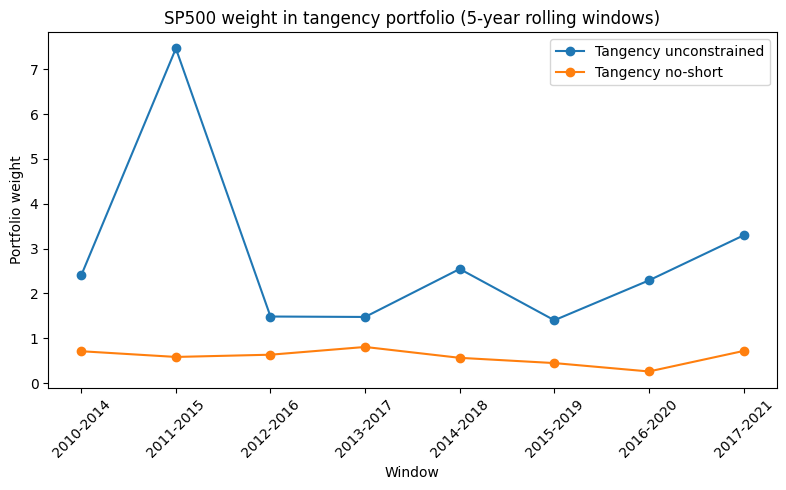

In [57]:
plt.figure(figsize=(8,5))

plt.plot(tan_uncon_weights_df.index,
         tan_uncon_weights_df["SP500"],
         marker="o",
         label="Tangency unconstrained")

plt.plot(tan_noshort_weights_clean_df.index,
         tan_noshort_weights_clean_df["SP500"],
         marker="o",
         label="Tangency no-short")

plt.title("SP500 weight in tangency portfolio (5-year rolling windows)")
plt.xlabel("Window")
plt.ylabel("Portfolio weight")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The plot shows how the S&P 500 weight in the tangency portfolio evolves across
the 5-year rolling windows. In the unconstrained case (blue line), the weight
is very unstable and can become extremely large: in the 2011–2015 window the
optimizer wants a position of more than 700% of wealth in the S&P 500,
financed by shorting other indices. Even in the other windows the S&P 500
weight often remains well above 100%, which is only possible because we allow
for leverage and short-selling.

With the no short-sale constraint (orange line), the S&P 500 weight is much
better behaved: it always stays between 0 and 1 and fluctuates in a more
reasonable range, typically between 25% and 80%. The S&P 500 is still the core
of the tangency portfolio in most windows, but the allocation looks far more
realistic. This graph nicely illustrates how the unconstrained mean–variance
solution is both aggressive and unstable over time, while the long-only
version is more constrained but also much more sensible from a practical
perspective.

### 3.3 Comparison with market cap-based weights

Finally, we compare our mean–variance tangency portfolios with a more
realistic benchmark: a portfolio weighted by the market capitalization
of each index. The Excel file provides these market-cap shares in the
sheet `market_cap`. We read these weights, align them with our eight
indices, and contrast them with the tangency portfolios in the last
5-year window (2017–2021).

In [58]:
# Read the market_cap sheet
mkt_raw = pd.read_excel(FILE, sheet_name="market_cap", header=1)
mkt_raw.columns = [str(c).strip() for c in mkt_raw.columns]

mkt_raw

,Unnamed: 0,SPTSX INDEX,CAC INDEX,DAX INDEX,SX5E INDEX,NKY INDEX,UKX INDEX,SPX INDEX,IBOV INDEX
0,NaN,0.041834,0.04318,0.036197,0.090955,0.092523,0.081589,0.602344,0.011378


To build the market-cap benchmark, we read the first row of the `market_cap`
sheet, which contains the capitalization share of each index. We then map the
Bloomberg tickers from the Excel file (e.g. `SPTSX INDEX`, `SPX INDEX`) to our
own column names (`TSX`, `SP500`, etc.), and construct a `Series` of
market-cap weights. Finally, we reorder this `Series` to match the order of
our `assets` list so that it lines up perfectly with the mean–variance
portfolios, and we check that the weights sum to one.

In [59]:
row = mkt_raw.iloc[0]

col_map = {
    "SPTSX INDEX": "TSX",
    "CAC INDEX": "CAC",
    "DAX INDEX": "DAX",
    "SX5E INDEX": "Eurostoxx50",
    "NKY INDEX": "NIKKEI225",
    "UKX INDEX": "FTSE100",
    "SPX INDEX": "SP500",
    "IBOV INDEX": "IBOVESPA",
}

# Build Series in the same order as our 'assets' list
w_mkt_dict = {}
for excel_name, our_name in col_map.items():
    w_mkt_dict[our_name] = float(row[excel_name])

w_mkt_series = pd.Series(w_mkt_dict)
w_mkt_series = w_mkt_series[assets]      # we reorder to TSX, CAC, ..., IBOVESPA

w_mkt_series, w_mkt_series.sum()

(TSX            0.041834
 CAC            0.043180
 DAX            0.036197
 Eurostoxx50    0.090955
 NIKKEI225      0.092523
 FTSE100        0.081589
 SP500          0.602344
 IBOVESPA       0.011378
 dtype: float64,
 np.float64(0.9999999999999999))

The vector above gives us the market-cap weights for our eight indices, and
they sum essentially to 1 (up to numerical rounding). The picture is very
reasonable: the S&P 500 dominates the portfolio with a weight of about 60%,
which reflects the fact that the US equity market is much larger than the
others in the sample. The remaining 40% is spread across the other regions
with relatively small but strictly positive allocations (roughly 4-9% for
Europe, Canada, Japan and the UK, and about 1% for Brazil). This is exactly
what we would expect from a global market-cap portfolio: highly tilted
towards the US, but still diversified across all the main markets.

To make the comparison concrete, we now focus on the last 5-year window
(2017-2021). We extract the tangency weights for that window, both with and
without short-selling, and place them side by side with the market-cap
weights in a single DataFrame. This will let us see, index by index, how far
the mean–variance portfolios are from a simple market-cap benchmark.

In [60]:
w_mv_uncon_last   = tan_uncon_weights_df.loc["2017-2021"]
w_mv_noshort_last = tan_noshort_weights_clean_df.loc["2017-2021"]

compare_weights = pd.DataFrame({
    "MarketCap": w_mkt_series,
    "MV_Tangency_Uncon_2017_2021": w_mv_uncon_last,
    "MV_Tangency_NoShort_2017_2021": w_mv_noshort_last,
}, index=assets)

compare_weights

,MarketCap,MV_Tangency_Uncon_2017_2021,MV_Tangency_NoShort_2017_2021
TSX,0.041834,-1.989785,0.000000
CAC,0.043180,9.771719,0.000000
DAX,0.036197,3.828330,0.000000
Eurostoxx50,0.090955,-11.893582,0.000000
NIKKEI225,0.092523,0.819020,0.280432
FTSE100,0.081589,-2.870681,0.000000
SP500,0.602344,3.295444,0.719568
IBOVESPA,0.011378,0.039536,0.000000


The table above compares three portfolios for the last window (2017-2021):
the market cap-based benchmark, the unconstrained tangency portfolio, and
the no-short tangency portfolio.

The market-cap portfolio is broadly diversified. The S&P 500 gets the largest
weight (about 60%), but all the other indices still have a positive share,
typically between 1% and 9%. This looks like a realistic global equity
portfolio that a passive investor could actually hold.

The unconstrained tangency portfolio is completely different. It takes very
large long and short positions - for example a huge long in the CAC and a
huge short in the Eurostoxx 50 - even though the weights still sum to one.
This is a highly leveraged long-short portfolio: it delivers a high Sharpe
ratio on paper, but it is very far from what a typical long-only investor
would implement in practice.

The no-short tangency portfolio is more realistic in the sense that it is
long-only, but it remains very concentrated: almost all the weight goes to
the S&P 500, with the rest allocated to the Nikkei and zero exposure to the
other indices. Compared to the smooth market-cap allocation, the two
mean-variance portfolios look much more aggressive and unstable, which
highlights the gap between the textbook Markowitz solution and a simple
market-cap benchmark.

To visualise these differences more clearly, we now plot the three sets of
weights (market-cap, unconstrained tangency, and no-short tangency) for the
2017-2021 window on a single bar chart. This makes it easier to see, for each
index, how far the mean-variance portfolios move away from the simple
market-cap allocation.

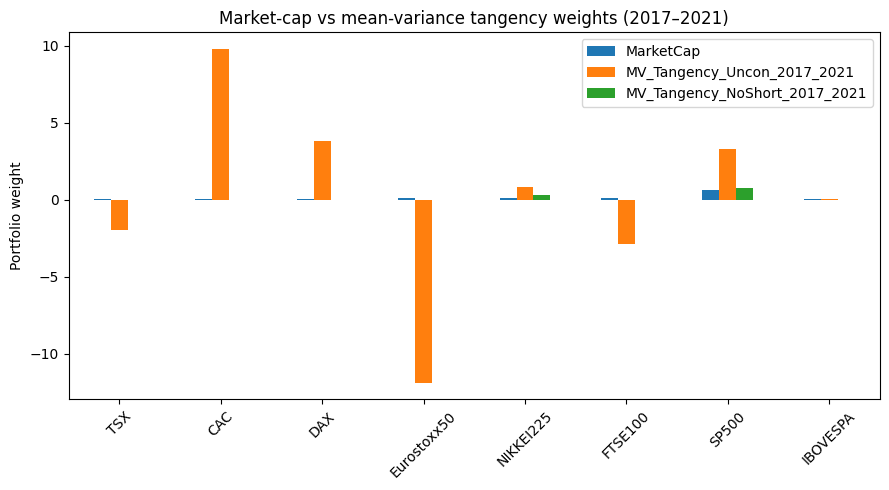

In [61]:
compare_weights.plot(kind="bar", figsize=(9,5))
plt.title("Market-cap vs mean-variance tangency weights (2017–2021)")
plt.ylabel("Portfolio weight")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart makes the contrast between the three portfolios very clear.

The blue bars (MarketCap) form a smooth, low-level profile: the S&P 500 gets
the largest weight, but all other indices have small positive weights as well.
This is what a diversified global equity portfolio looks like in practice.

The orange bars (MV_Tangency_Uncon_2017_2021) are completely different. The
weights are huge in absolute value and alternate between large longs and large
shorts (e.g. very long CAC and DAX, very short Eurostoxx50 and FTSE100). This
is the classic Markowitz tangency portfolio with short-selling allowed: highly
leveraged, very concentrated and not at all similar to a realistic long-only
investment.

The green bars (MV_Tangency_NoShort_2017_2021) sit in between. The portfolio
is long-only, but still very concentrated: almost all the weight is on the
S&P 500, with a smaller allocation to the Nikkei and zero exposure to the
other indices. Compared to the blue market-cap bars, the green profile is much
less diversified, which shows again how aggressive the mean-variance solution
remains even after imposing no short-sales.

Overall, the rolling-window analysis shows that mean-variance tangency
portfolios are very unstable over time. With short-selling allowed, the
weights become highly leveraged long-short positions that change sign across
windows. Imposing a no short-sale constraint makes the portfolios more
reasonable, but they remain strongly concentrated on a few indices (mainly
the S&P 500 and, in some periods, the Nikkei and Ibovespa).

In contrast, the market-cap portfolio is stable and well diversified across
all markets. The comparison highlights the gap between the theoretical
Markowitz solution based on estimated moments and a simple market-cap
benchmark that a realistic investor might actually hold.